In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749145897.974327   27098 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749145897.983639   27098 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749145898.007989   27098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749145898.008033   27098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749145898.008035   27098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749145898.008037   27098 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.3 Improving model fit

To achieve the perfect fit, you must first overfit. Since you don’t know in advance
where the boundary lies, you must cross it to find it.

Thus your initial goal as you start on a problem is to achieve a model that shows some
generalization power and that is able to overfit.  Once you have such a model, you'll focus
on refining generalization by fighting overfitting.

There are 3 common problems you'll encounter when starting:

1. Training doesn’t get started: your training loss doesn’t go down over time.
2. Training gets started just fine, but your model doesn’t meaningfully generalize:
   you can’t beat the common-sense baseline you set.
3. Training and validation loss both go down over time, and you can beat your
   baseline, but you don’t seem to be able to overfit, which indicates you’re still
   underfitting.

### 5.3.1 Tuning key gradient descent parameters

Sometimes training doesn’t get started, or it stalls too early. Your loss is stuck. This is
always something you can overcome. When this happens, it’s always a problem with the configuration of the gradient
descent process: your choice of optimizer, the distribution of initial values in the
weights of your model, your learning rate, or your batch size. All these parameters are
interdependent, and as such it is usually sufficient to tune the learning rate and the
batch size while keeping the rest of the parameters constant.

Let's look at a concrete example of what we are talking about here.  Let's train MNIST model
from before with an inappropriately large learning rate value of 1.  The training loss might decrease
a bit, but it will quickly stop, and maybe even increase on the training data, which indicates
divergence.

In [4]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# notice the parameter to RMSprop, this sets the learning rate to 1
model.compile(optimizer=keras.optimizers.RMSprop(1.0),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

I0000 00:00:1749146569.872700   27098 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1749146571.327771   28819 service.cc:152] XLA service 0x70f1d8017de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749146571.328050   28819 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1749146571.522109   28819 cuda_dnn.cc:529] Loaded cuDNN version 90300


 58/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5153 - loss: 10839.8623

I0000 00:00:1749146574.129827   28819 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4282 - loss: 2687.1248 - val_accuracy: 0.2216 - val_loss: 2.1786
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2171 - loss: 4.0121 - val_accuracy: 0.1802 - val_loss: 2.3467
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2082 - loss: 2.8250 - val_accuracy: 0.2067 - val_loss: 2.1367
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2296 - loss: 2.3147 - val_accuracy: 0.2016 - val_loss: 2.1201
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2116 - loss: 2.3002 - val_accuracy: 0.2359 - val_loss: 2.0629
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2277 - loss: 2.2860 - val_accuracy: 0.1939 - val_loss: 2.1721
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2069 - loss: 2.3391 - val_accuracy: 0.2015 - val_loss: 2.4168
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2119 - loss: 2.3302 - val_accuracy: 0.2136 - v

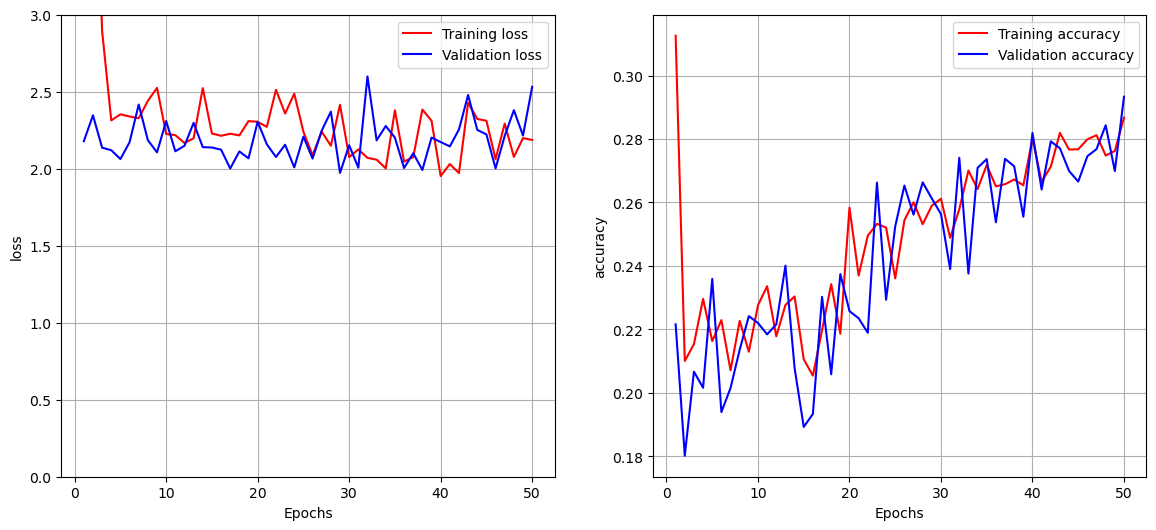

In [5]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model quickly reaches a training validation accuracy in the 25% range, but cannot get past that.  Let's lower the learning rate to a
more reasonable value of `1e-2`.

In [6]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# only difference from before, set learning rate to 0.01
model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8386 - loss: 0.7685 - val_accuracy: 0.9518 - val_loss: 0.1676
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9645 - loss: 0.1257 - val_accuracy: 0.9590 - val_loss: 0.1475
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9756 - loss: 0.0899 - val_accuracy: 0.9695 - val_loss: 0.1231
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9786 - loss: 0.0789 - val_accuracy: 0.9728 - val_loss: 0.1399
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0636 - val_accuracy: 0.9668 - val_loss: 0.1800
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9869 - loss: 0.0481 - val_accuracy: 0.9710 - val_loss: 0.1798
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9885 - loss: 0.0462 - val_accuracy: 0.9694 - val_loss: 0.1918
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9899 - loss: 0.0395 - val_accuracy: 0.

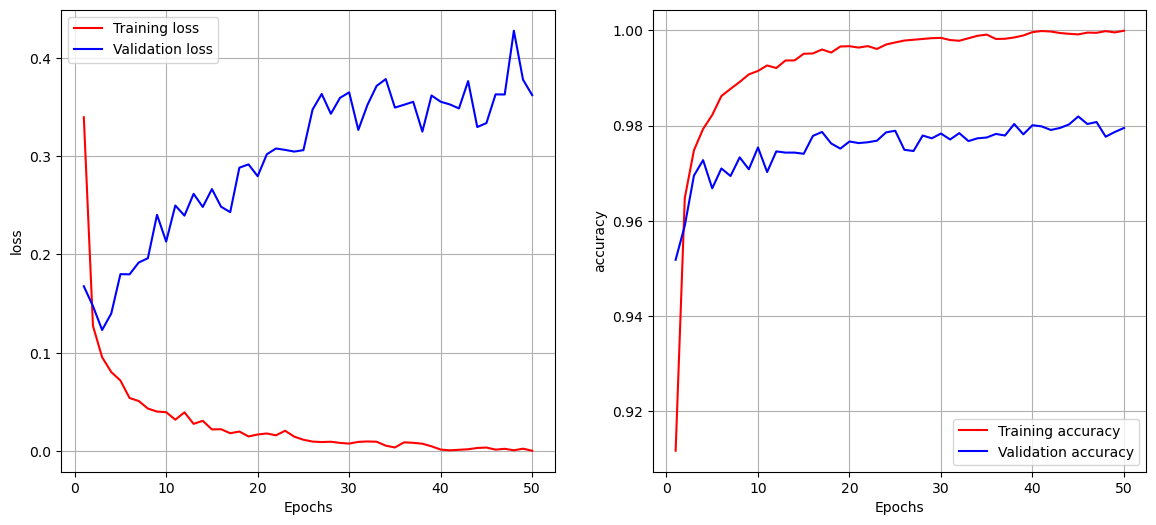

In [7]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
#ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

These learning curves look much more reasonable.  Not only is accuracy much better, but the training loss actually steadily decreases
for 30 epochs or so, indicating that it is fiting the data.

If you find yourself in a similar situation, try:

- Lowering or increasing the learning rate. A learning rate that is too high may
  lead to updates that vastly overshoot a proper fit, like in the preceding example,
  and a learning rate that is too low may make training so slow that it appears
  to stall.
- Increasing the batch size. A batch with more samples will lead to gradients that
  are more informative and less noisy (lower variance).

### 5.3.2 Leveraging better architecture priors

- Your model trains but doesn't generalize
  - train loss and metric decrease
  - but validation loss stays same and validation metric is no better than baseline / random
- **The worst** ML situation you can find yourself it, **something is fundamentally wrong with your approach**.

1. The input data may not contain sufficient information to reliably make predictions (think of training on randomized data).
2. Hopefully, instead the kind of model you're using may not be suited for the problem (e.g. is it image processing?, a timeseries?)
   - Using a model that makes the right assumpitons about the problem is **essential** to achieving generalization.
### 5.3.3 Increasing model capacity

If your model seems to be fitting the training data, and your validation metrics are going down and it seems to achieve at least some level
of generalization, then, you next need to get your model to start overfitting.

For example, consider using a simple logistic regression trained on MNIST dataset.

In [8]:
# remember that a logistic regression is really equivalent to a
# neural network with a single layer performing a tensor multiply
# of weight parameters and a tensor addition to the bias parameters
model = keras.Sequential([layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels,
                                epochs=20,
                                batch_size=128,
                                validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7345 - loss: 1.0502 - val_accuracy: 0.9033 - val_loss: 0.3590
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9027 - loss: 0.3626 - val_accuracy: 0.9136 - val_loss: 0.3082
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9101 - loss: 0.3204 - val_accuracy: 0.9173 - val_loss: 0.2928
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9145 - loss: 0.3061 - val_accuracy: 0.9234 - val_loss: 0.2839
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9197 - loss: 0.2908 - val_accuracy: 0.9246 - val_loss: 0.2776
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9196 - loss: 0.2875 - val_accuracy: 0.9252 - val_loss: 0.2742
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9219 - loss: 0.2836 - val_accuracy: 0.9265 - val_loss: 0.2713
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9234 - loss: 0.2781 - val_accuracy: 0.

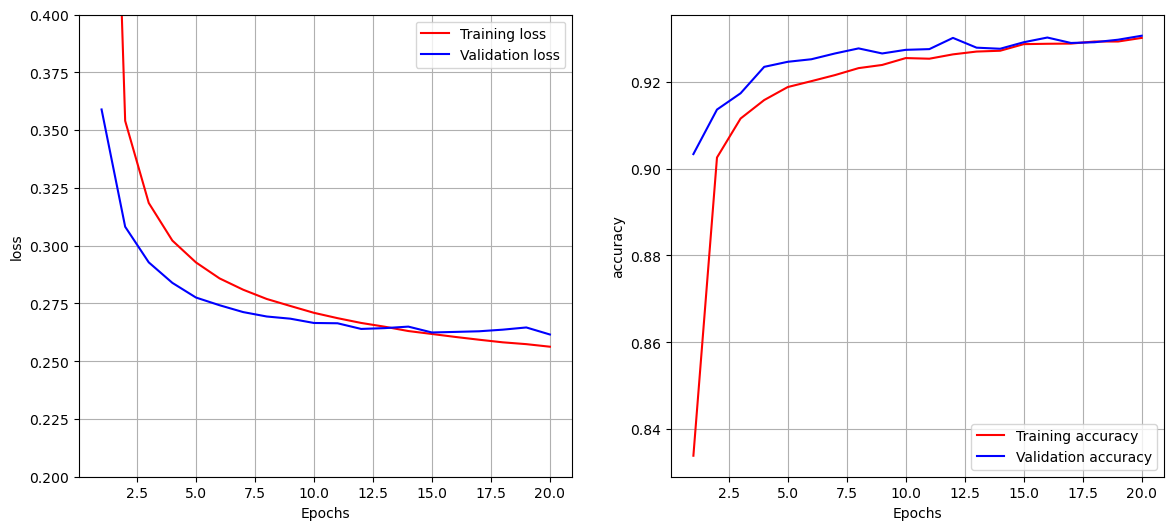

In [9]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_small_model.history, 'loss')
ax_loss.set_ylim(0.2, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_small_model.history, 'accuracy')

What we are looking at here is the validation loss.  Validation loss seem to stall or are improving very slowly.
Instead if the model is sufficiently powerful, we would expect overfitting.  The validation loss
goes to 0.26 and just stays there.  You can fit, but you can't clearly overfit.

The sign of a model that is overfitting is that validation loss will go down to some minimum, but will begin to increase again
once overfitting begins to occur.  Remember that it should always be possible to overfit.  We saw that a neural
network can fit random data if you tell it to. If you can't seem to be able to overfit, it's likely a problem
with the **representational power** of your model. You need a bigger model with more **capacity**.

You can increate representational power by adding more layers, using bigger layers, or using kinds of
layers more appropriate to the problem.

For example, if we use a bigger model we can easily get the model to overfit.

In [10]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(
    train_images, train_labels,
    epochs=40,
    batch_size=128,
    validation_split=0.2)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8267 - loss: 0.6347 - val_accuracy: 0.9482 - val_loss: 0.1827
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9493 - loss: 0.1728 - val_accuracy: 0.9599 - val_loss: 0.1431
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9649 - loss: 0.1173 - val_accuracy: 0.9655 - val_loss: 0.1238
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9719 - loss: 0.0914 - val_accuracy: 0.9705 - val_loss: 0.1005
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9800 - loss: 0.0687 - val_accuracy: 0.9713 - val_loss: 0.0980
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9726 - val_loss: 0.0961
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9865 - loss: 0.0477 - val_accuracy: 0.9699 - val_loss: 0.1083
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0

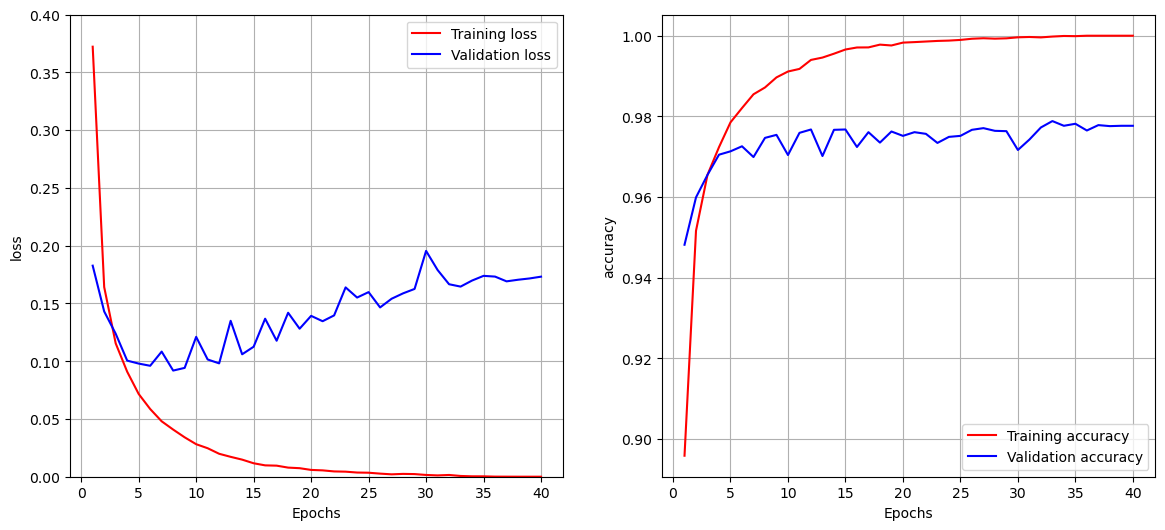

In [11]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_large_model.history, 'loss')
ax_loss.set_ylim(0.00, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_large_model.history, 'accuracy')

The validation loss for a model with appropriate capacity looks something like the loss figure here.  
Training loss continues to improve steadily.  But validation loss decreases till epoch 5 to 10,
then clearly begins to creep back up again.  The model is overfitting here, learning the
noise in the data which decreases generalization.

## Summary 

To recap, here is what you should remember about how to evaluate machine learning models effectively.

<font color='blue'>

- If training doesn't get started and loss doesn't go down for the training data, change the configuration of your optimizer.
  - Try increasing or decreasing the learning rate, using a different optimizer, increasing or decreasing the batch size.
- If you model fits (training loss goes down) but validation metrics don't generalize (stay at random baseline)
  - This could mean your data doesn't have sufficient information to predict your targets
  - Could mean that you need to use an architecture more suitable to the type of data, like CNN for image data or LSTM for sequence data.
- If your model fits and validation metrics are beating baseline, but validation loss never goes back up your model is not overfitting.
  - You need to cross the line of overfitting to know where the line is.
  - Increase the model capacity, add more layers and/or more units to layers.